<a href="https://colab.research.google.com/github/devashishbadoni95-maker/Netflix-EDA-Data-Analysis/blob/main/Project_01_Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. CSV file ko load karna
df = pd.read_csv('netflix_titles.csv')

# Data ki shuruati 5 rows dekhna
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
# 1. Jo columns me text missing hai, unhe 'Unknown' se fill karna
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# 2. Rating, duration aur date_added me bohot kam null values hain, un rows ko drop karna
df = df.dropna(subset=['rating', 'duration', 'date_added']).copy()

# 3. date_added ko Datetime format me badalna aur saal alag column me store karna
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

# 4. Check karna ki koi missing value bachi hai ya nahi
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())
print("\nFinal Clean Data Shape:", df.shape)

--- Missing Values After Cleaning ---
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

Final Clean Data Shape: (8790, 13)


In [10]:
# 1. Movies vs TV Shows
print("--- Q1: Content Type Breakdown ---")
print(df['type'].value_counts())

# 2. Top 10 Countries
print("\n--- Q2: Top 10 Countries ---")
print(df[df['country'] != 'Unknown']['country'].value_counts().head(10))

# 3. Content added by year
print("\n--- Q3: Content Added by Year ---")
print(df['year_added'].value_counts().sort_index())

# 4. Top 10 Genres
print("\n--- Q4: Top 10 Genres ---")
print(df['listed_in'].str.split(', ').explode().value_counts().head(10))

# 5. Content ratings distribution
print("\n--- Q5: Rating Distribution ---")
print(df['rating'].value_counts())

--- Q1: Content Type Breakdown ---
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

--- Q2: Top 10 Countries ---
country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

--- Q3: Content Added by Year ---
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

--- Q4: Top 10 Genres ---
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies     

/tmp/ipykernel_795/1815065320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


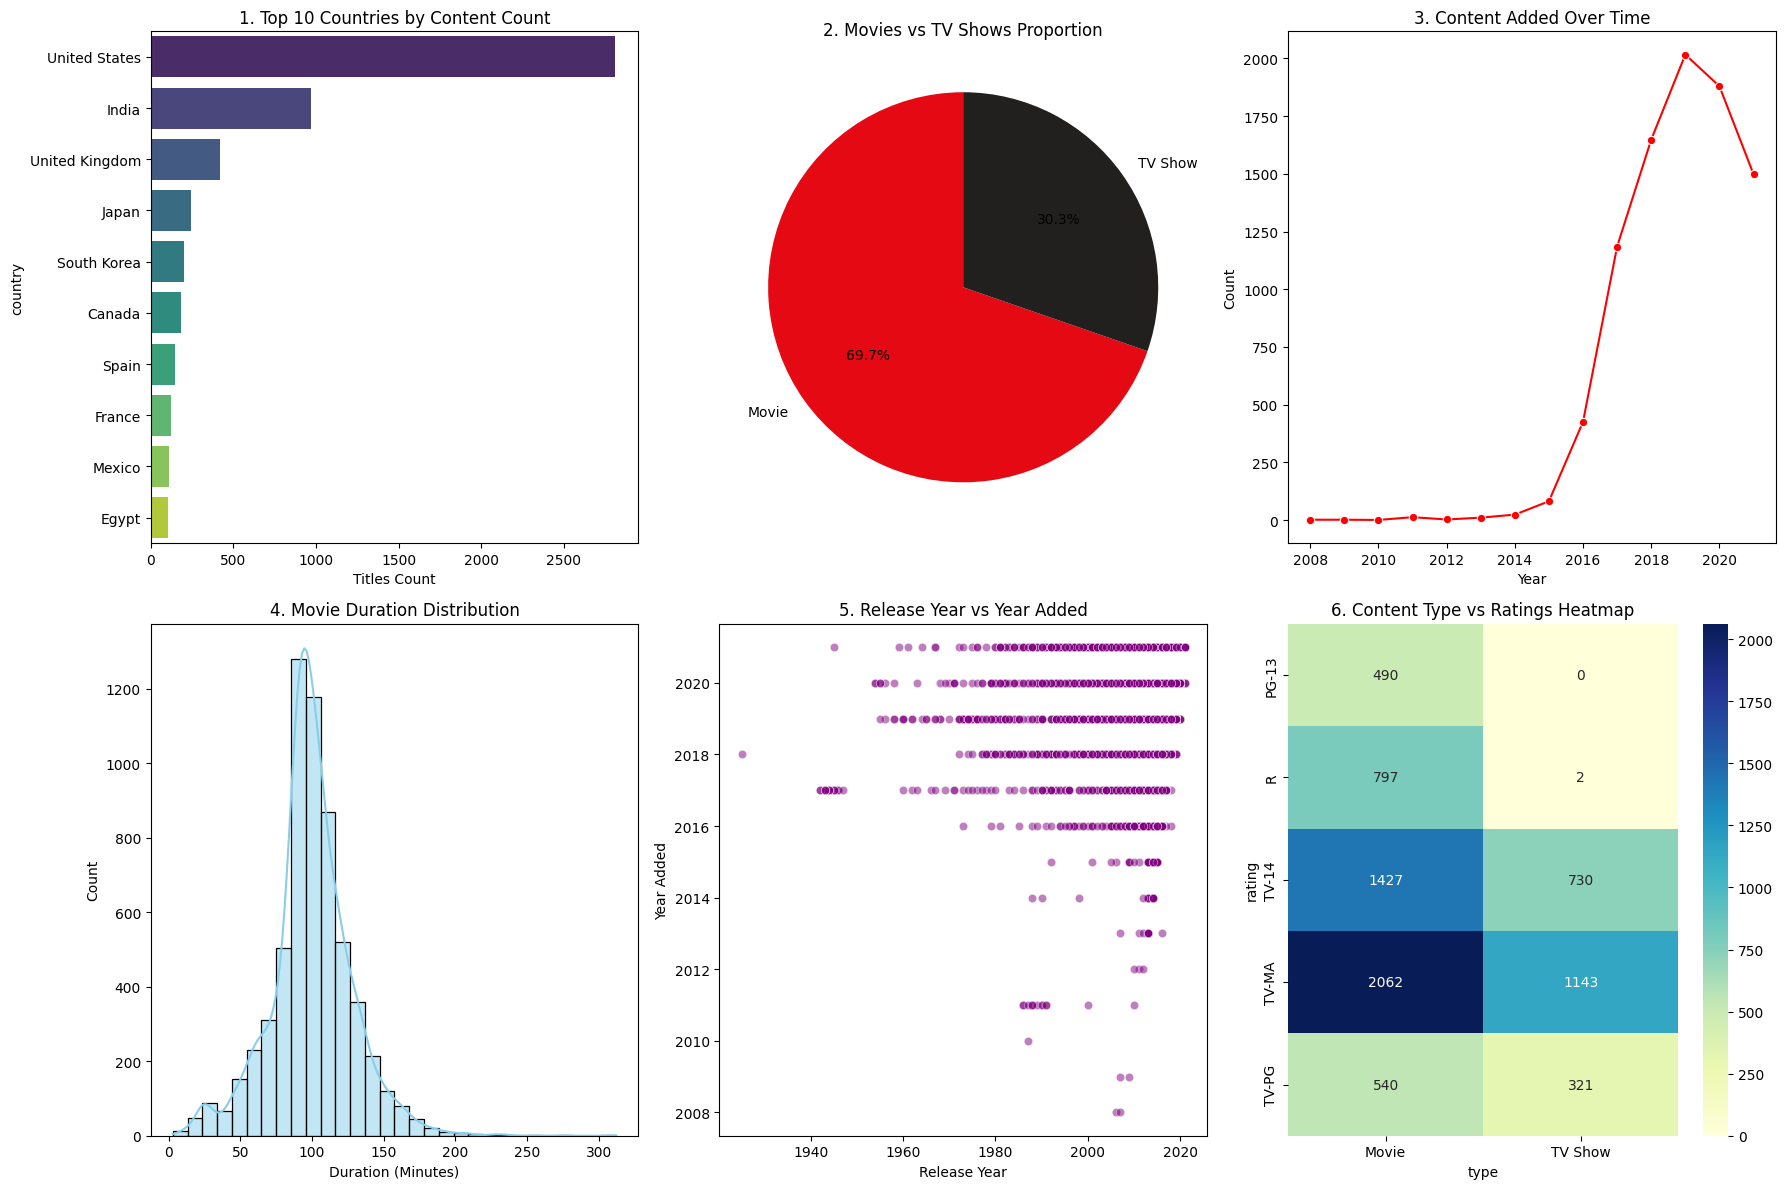

In [11]:
plt.figure(figsize=(18, 12))

# 1. Bar Chart
plt.subplot(2, 3, 1)
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('1. Top 10 Countries by Content Count')
plt.xlabel('Titles Count')

# 2. Pie Chart
plt.subplot(2, 3, 2)
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#e50914', '#221f1f'], startangle=90)
plt.title('2. Movies vs TV Shows Proportion')
plt.ylabel('')

# 3. Line Chart
plt.subplot(2, 3, 3)
content_by_year = df['year_added'].value_counts().sort_index()
sns.lineplot(x=content_by_year.index, y=content_by_year.values, marker='o', color='red')
plt.title('3. Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')

# 4. Histogram
plt.subplot(2, 3, 4)
movie_dur = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').dropna().astype(int)
sns.histplot(movie_dur, bins=30, kde=True, color='skyblue')
plt.title('4. Movie Duration Distribution')
plt.xlabel('Duration (Minutes)')

# 5. Scatter Plot
plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x='release_year', y='year_added', alpha=0.5, color='purple')
plt.title('5. Release Year vs Year Added')
plt.xlabel('Release Year')
plt.ylabel('Year Added')

# 6. Heatmap
plt.subplot(2, 3, 6)
top_ratings = df['rating'].value_counts().head(5).index
top_types = df[df['rating'].isin(top_ratings)]
ct = pd.crosstab(top_types['rating'], top_types['type'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('6. Content Type vs Ratings Heatmap')

plt.tight_layout()
plt.show()

### Insights Report (5 Business Findings)
1. **Catalog Composition:** Movies constitute approximately 70% of the entire library, while TV Shows account for around 30%.
2. **Geographical Concentration:** The United States and India are the leading contributors of global catalog volume.
3. **Platform Expansion:** Platform content acquisitions peaked between 2017 and 2019, reflecting aggressive global scaling during this timeframe.
4. **Runtime Trends:** Standard movie length is concentrated around 90–100 minutes, indicating user viewing preferences.
5. **Audience Segmentation:** Mature content (TV-MA) and Young Adult content (TV-14) dominate the catalog ratings.

### Most Surprising Finding:
A substantial volume of classic and vintage films (released prior to 2000) were acquired and uploaded in batches around 2018–2020 to build library depth.